Blinkit Sales & Customer Analysis using Pandas

#Objective
Analyze Blinkit sales data to identify top categories, high-revenue products, and customer behavior.

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [134]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')   # clean professional

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
orders = pd.read_csv("blinkit_orders.csv")
orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,17-07-2024 08:34,17-07-2024 08:52,17-07-2024 08:47,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,28-05-2024 13:14,28-05-2024 13:25,28-05-2024 13:27,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,23-09-2024 13:07,23-09-2024 13:25,23-09-2024 13:29,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,24-11-2023 16:16,24-11-2023 16:34,24-11-2023 16:33,On Time,440.23,Card,61497,7917
4,5427684290,83298567,20-11-2023 05:00,20-11-2023 05:17,20-11-2023 05:18,On Time,2526.68,Cash,84315,2741


In [137]:
orders.shape

(5000, 10)

In [138]:
orders.columns


Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='object')

In [139]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [140]:
orders.isnull().sum()

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

In [141]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

C:\Users\muska_d01xzd7\AppData\Local\Temp\ipykernel_1508\77579792.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['order_date'] = pd.to_datetime(orders['order_date'])
C:\Users\muska_d01xzd7\AppData\Local\Temp\ipykernel_1508\77579792.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
C:\Users\muska_d01xzd7\AppData\Local\Temp\ipykernel_1508\77579792.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])


In [142]:
orders['delivery_time_minutes'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

In [143]:
orders['order_id'].nunique()

5000

In [144]:
orders['order_total'].sum()

np.float64(11009308.5)

In [145]:
orders['order_total'].mean()

np.float64(2201.8617)

In [146]:
orders.groupby('payment_method')['order_total'].sum()

payment_method
Card      2865557.53
Cash      2770463.99
UPI       2658282.71
Wallet    2715004.27
Name: order_total, dtype: float64

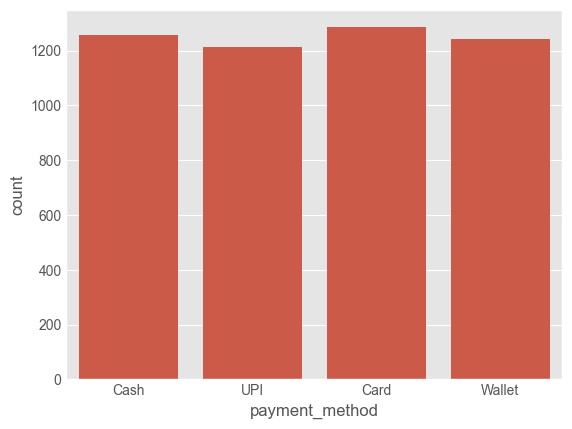

In [147]:
sns.countplot(x='payment_method', data=orders)
plt.show()

In [148]:
orders['delivery_status'].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

In [149]:
orders['delivery_status'].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

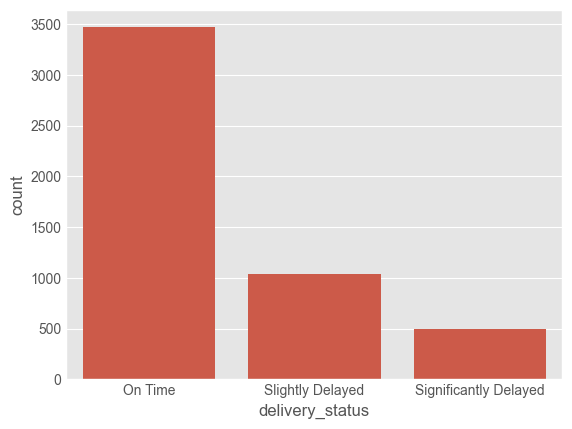

In [150]:
sns.countplot(x='delivery_status', data=orders)
plt.show()

In [151]:
orders['delivery_time_minutes'].mean()

np.float64(19.4344)

In [152]:
order_items = pd.read_csv("blinkit_order_items.csv")

In [153]:
products = pd.read_csv("blinkit_products.csv")

In [154]:
merged1 = pd.merge(orders, order_items, on="order_id")
merged = pd.merge(merged1, products, on="product_id")

In [155]:
orders = pd.read_csv("blinkit_orders.csv")
order_items = pd.read_csv("blinkit_order_items.csv")
products = pd.read_csv("blinkit_products.csv")

merged1 = pd.merge(orders, order_items, on="order_id")
merged = pd.merge(merged1, products, on="product_id")

In [156]:
orders['delivery_status'].value_counts(normalize=True) * 100

delivery_status
On Time                  69.40
Slightly Delayed         20.74
Significantly Delayed     9.86
Name: proportion, dtype: float64

In [157]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_day'] = orders['order_date'].dt.date

C:\Users\muska_d01xzd7\AppData\Local\Temp\ipykernel_1508\1659545148.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['order_date'] = pd.to_datetime(orders['order_date'])


In [158]:
import matplotlib.pyplot as plt

daily_revenue = merged.groupby('order_day')['price'].sum()

plt.figure(figsize=(12,5))
daily_revenue.plot()

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

KeyError: 'order_day'

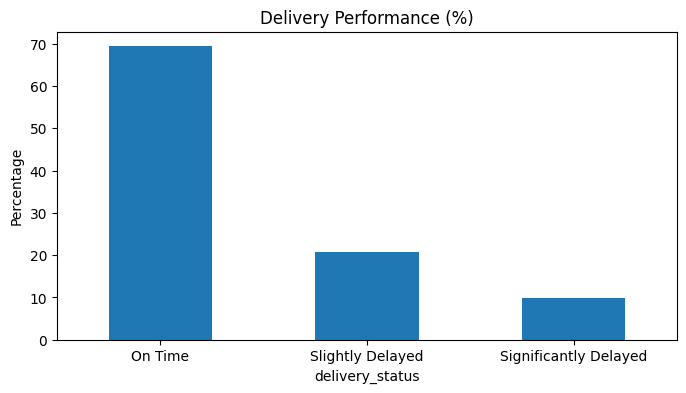

In [ ]:
status_pct = orders['delivery_status'].value_counts(normalize=True) * 100

status_pct.plot(kind='bar', figsize=(8,4), title="Delivery Performance (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [ ]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

orders['delivery_time_min'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

C:\Users\muska_d01xzd7\AppData\Local\Temp\ipykernel_1508\3038026178.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])


In [ ]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

orders['delivery_time_min'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

In [ ]:
customer_revenue = merged.groupby('customer_id')['price'].sum()

customer_revenue.describe()

count    2172.000000
mean     1135.262201
std       768.274123
min        12.320000
25%       552.200000
50%       971.975000
75%      1567.005000
max      5104.110000
Name: price, dtype: float64

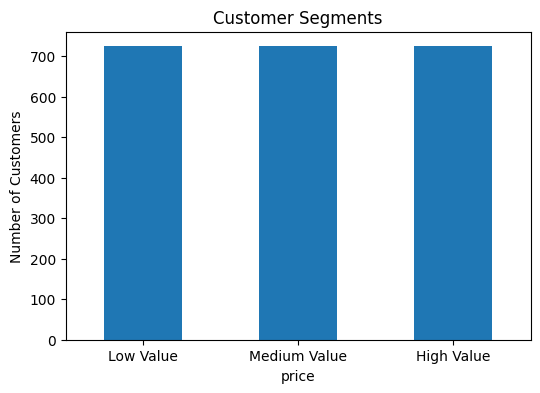

In [ ]:
customer_segment = pd.qcut(customer_revenue, q=3, labels=['Low Value','Medium Value','High Value'])

customer_segment.value_counts().plot(kind='bar', figsize=(6,4), title="Customer Segments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
customer_revenue.sort_values(ascending=False).head(10)

customer_id
77869660    5104.11
8791577     4677.54
26285589    4524.95
93018527    4176.53
25128143    4029.70
12832151    3919.08
12272282    3873.36
57291761    3838.36
20148223    3809.32
20956158    3801.77
Name: price, dtype: float64

In [ ]:
customer_revenue.sort_values(ascending=False).head(10)

customer_id
77869660    5104.11
8791577     4677.54
26285589    4524.95
93018527    4176.53
25128143    4029.70
12832151    3919.08
12272282    3873.36
57291761    3838.36
20148223    3809.32
20956158    3801.77
Name: price, dtype: float64

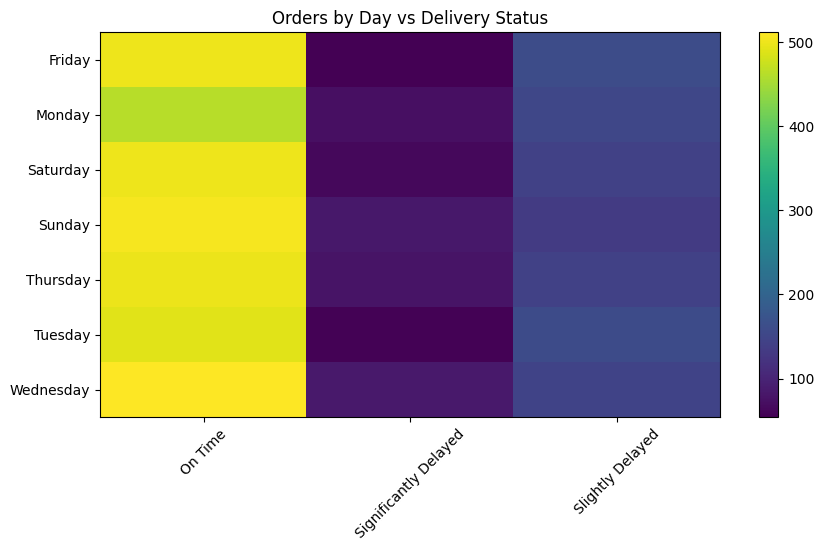

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['day'] = orders['order_date'].dt.day_name()

heatmap_data = pd.crosstab(orders['day'], orders['delivery_status'])

plt.figure(figsize=(10,5))
plt.imshow(heatmap_data, aspect='auto')
plt.title("Orders by Day vs Delivery Status")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar()
plt.show()

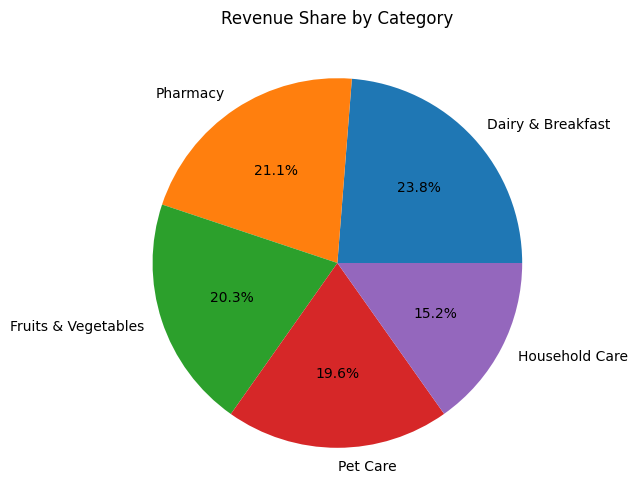

In [ ]:
category_revenue = merged.groupby('category')['price'].sum().sort_values(ascending=False).head()

category_revenue.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title="Revenue Share by Category")
plt.ylabel("")
plt.show()

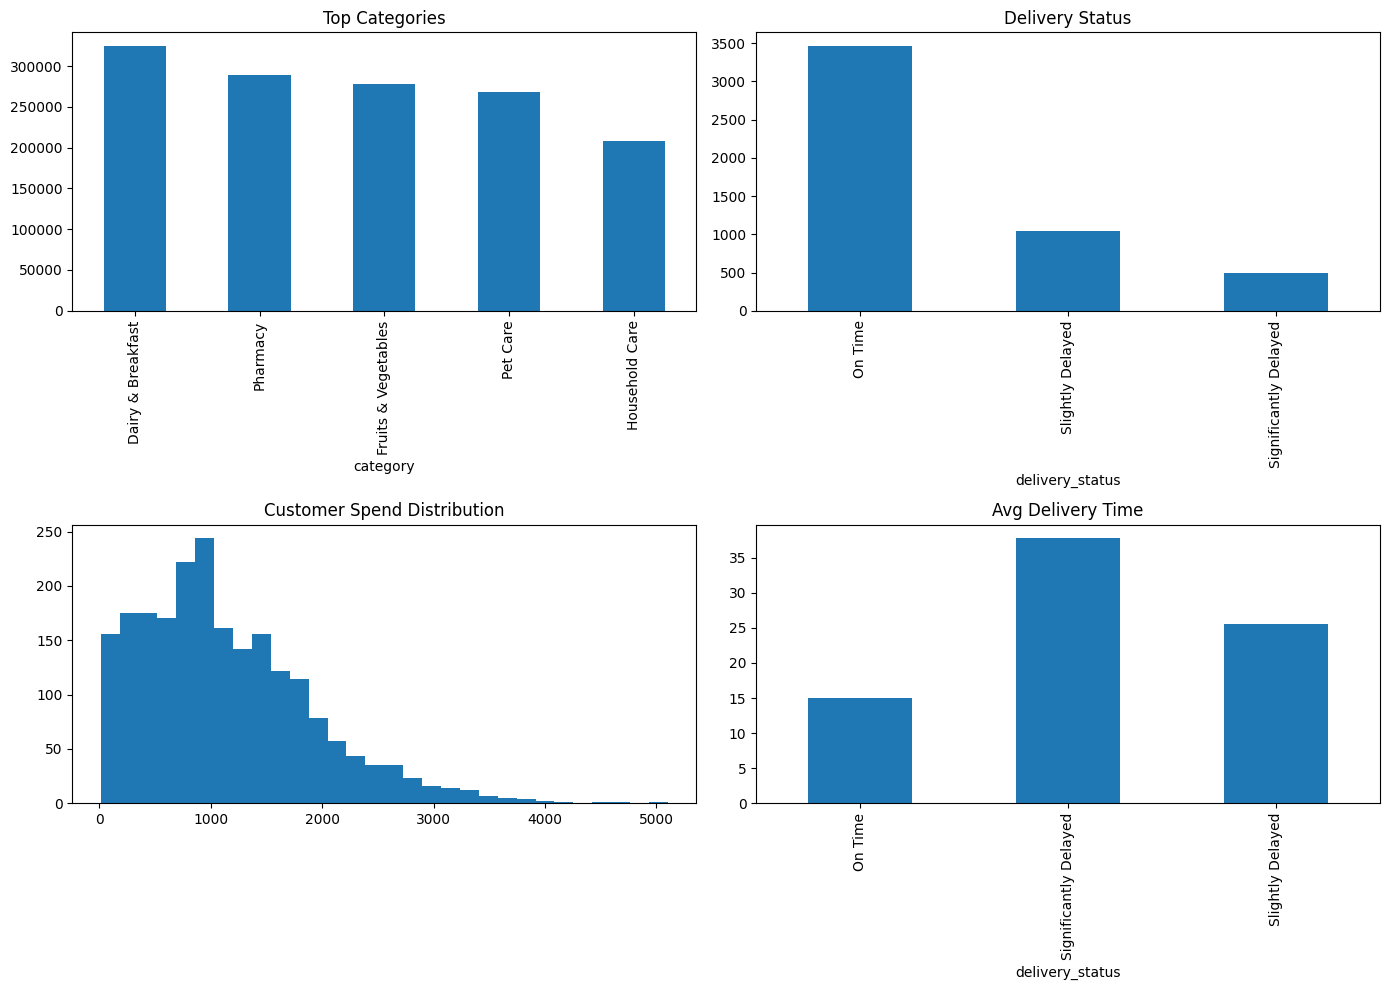

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Top Categories
merged.groupby('category')['price'].sum().sort_values(ascending=False).head().plot(
    kind='bar', ax=axes[0,0], title="Top Categories"
)

# 2. Delivery Status
orders['delivery_status'].value_counts().plot(
    kind='bar', ax=axes[0,1], title="Delivery Status"
)

# 3. Customer Spend Histogram
customer_revenue = merged.groupby('customer_id')['price'].sum()
axes[1,0].hist(customer_revenue, bins=30)
axes[1,0].set_title("Customer Spend Distribution")

# 4. Delivery Time by Status
orders.groupby('delivery_status')['delivery_time_min'].mean().plot(
    kind='bar', ax=axes[1,1], title="Avg Delivery Time"
)

plt.tight_layout()
plt.show()

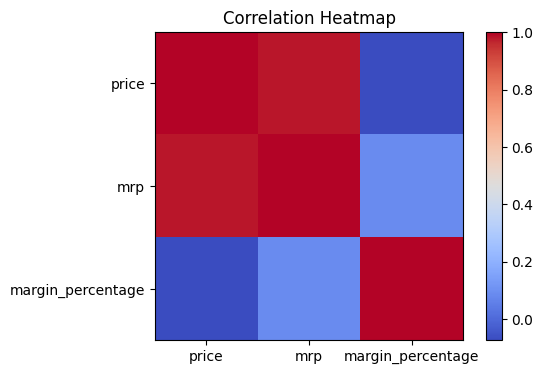

In [ ]:
corr = merged[['price','mrp','margin_percentage']].corr()

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap='coolwarm')
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

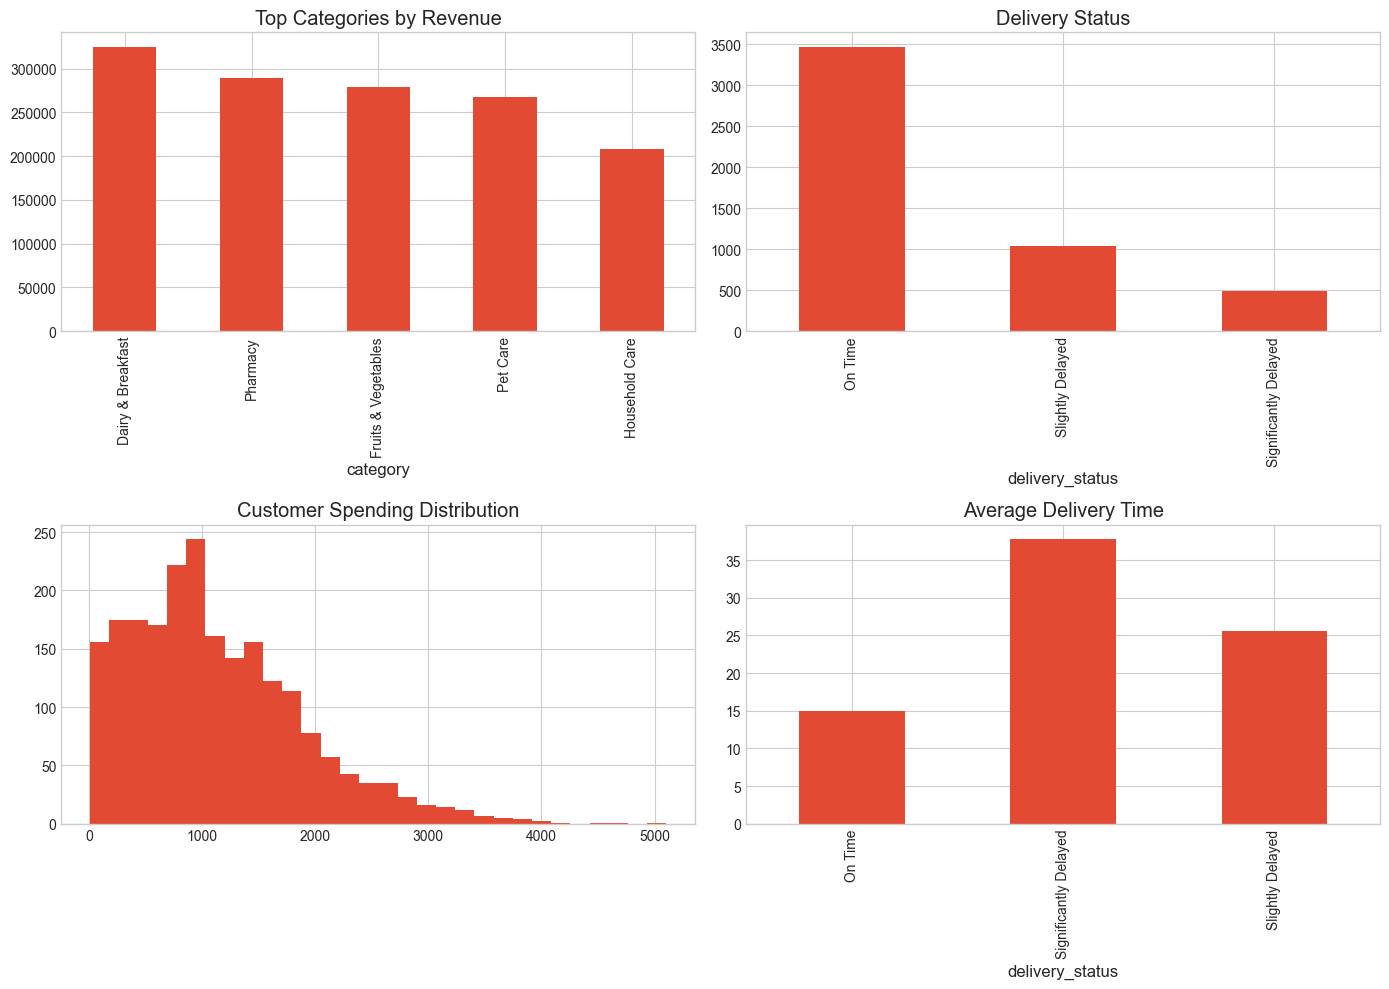

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Revenue by Category
merged.groupby('category')['price'].sum().sort_values(ascending=False).head().plot(
    kind='bar', ax=axes[0,0], title="Top Categories by Revenue"
)

# Delivery Status
orders['delivery_status'].value_counts().plot(
    kind='bar', ax=axes[0,1], title="Delivery Status"
)

# Customer Distribution
customer_revenue = merged.groupby('customer_id')['price'].sum()
axes[1,0].hist(customer_revenue, bins=30)
axes[1,0].set_title("Customer Spending Distribution")

# Avg Delivery Time
orders.groupby('delivery_status')['delivery_time_min'].mean().plot(
    kind='bar', ax=axes[1,1], title="Average Delivery Time"
)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

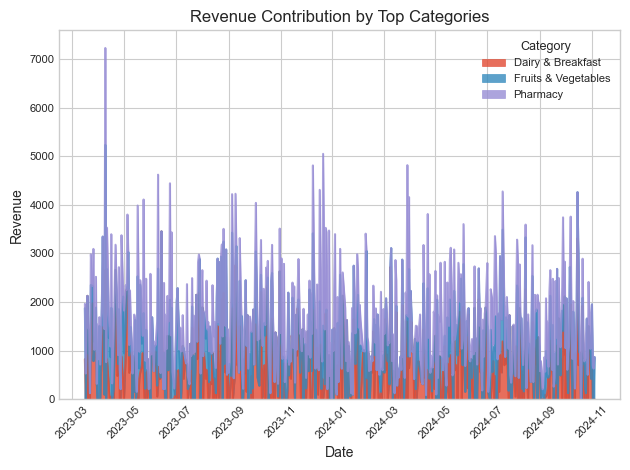

In [ ]:
plt.figure(figsize=(12,5))

trend.plot(kind='area', stacked=True, alpha=0.8)

plt.title("Revenue Contribution by Top Categories", fontsize=12)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Revenue", fontsize=10)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.legend(title="Category", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

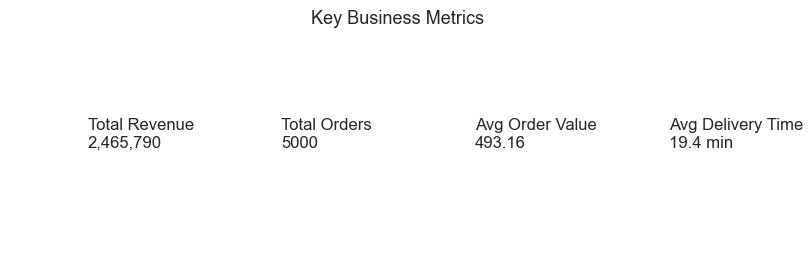

In [ ]:
total_revenue = merged['price'].sum()
total_orders = orders['order_id'].nunique()
avg_order_value = merged.groupby('order_id')['price'].sum().mean()
avg_delivery_time = orders['delivery_time_min'].mean()

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

ax.text(0.1, 0.5, f"Total Revenue\n{total_revenue:,.0f}", fontsize=12)
ax.text(0.35, 0.5, f"Total Orders\n{total_orders}", fontsize=12)
ax.text(0.6, 0.5, f"Avg Order Value\n{avg_order_value:.2f}", fontsize=12)
ax.text(0.85, 0.5, f"Avg Delivery Time\n{avg_delivery_time:.1f} min", fontsize=12)

plt.title("Key Business Metrics", fontsize=13)
plt.show()

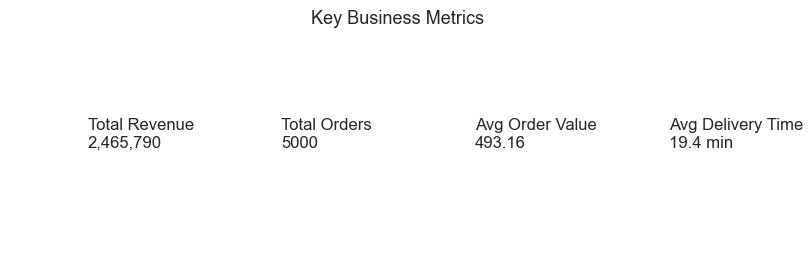

In [ ]:
total_revenue = merged['price'].sum()
total_orders = orders['order_id'].nunique()
avg_order_value = merged.groupby('order_id')['price'].sum().mean()
avg_delivery_time = orders['delivery_time_min'].mean()

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

ax.text(0.1, 0.5, f"Total Revenue\n{total_revenue:,.0f}", fontsize=12)
ax.text(0.35, 0.5, f"Total Orders\n{total_orders}", fontsize=12)
ax.text(0.6, 0.5, f"Avg Order Value\n{avg_order_value:.2f}", fontsize=12)
ax.text(0.85, 0.5, f"Avg Delivery Time\n{avg_delivery_time:.1f} min", fontsize=12)

plt.title("Key Business Metrics", fontsize=13)
plt.show()

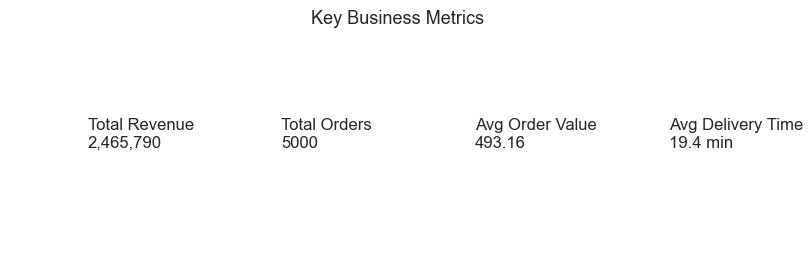

In [ ]:
total_revenue = merged['price'].sum()
total_orders = orders['order_id'].nunique()
avg_order_value = merged.groupby('order_id')['price'].sum().mean()
avg_delivery_time = orders['delivery_time_min'].mean()

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

ax.text(0.1, 0.5, f"Total Revenue\n{total_revenue:,.0f}", fontsize=12)
ax.text(0.35, 0.5, f"Total Orders\n{total_orders}", fontsize=12)
ax.text(0.6, 0.5, f"Avg Order Value\n{avg_order_value:.2f}", fontsize=12)
ax.text(0.85, 0.5, f"Avg Delivery Time\n{avg_delivery_time:.1f} min", fontsize=12)

plt.title("Key Business Metrics", fontsize=13)
plt.show()

In [ ]:
summary = merged.groupby('category').agg(
    total_revenue=('price','sum'),
    avg_price=('price','mean'),
    total_orders=('order_id','nunique')
).sort_values('total_revenue', ascending=False)

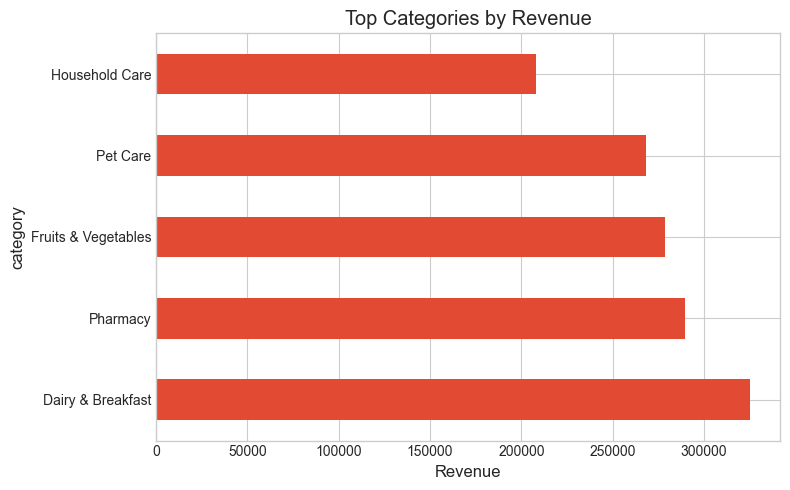

In [ ]:
summary['total_revenue'].head(5).plot(
    kind='barh',
    figsize=(8,5),
    title="Top Categories by Revenue"
)

plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

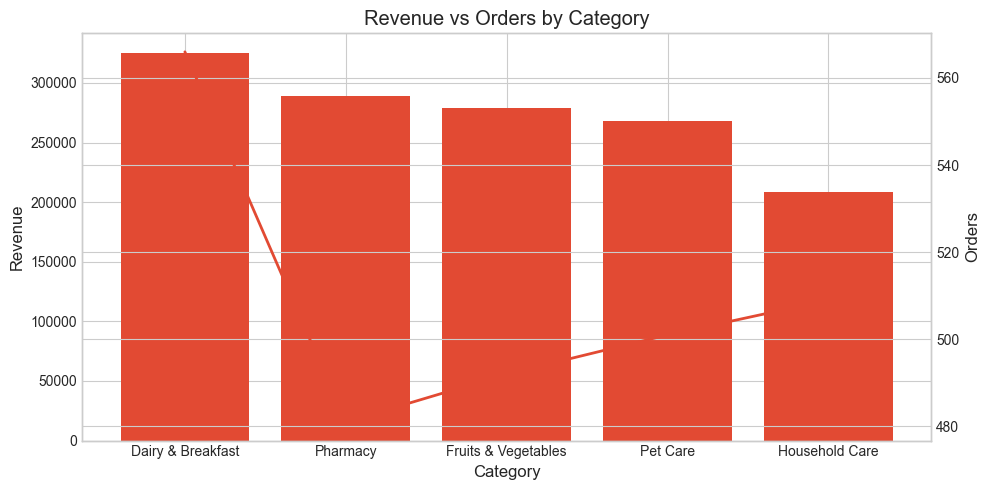

In [ ]:
category_stats = merged.groupby('category').agg(
    revenue=('price','sum'),
    orders=('order_id','nunique')
).sort_values('revenue', ascending=False).head(5)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(category_stats.index, category_stats['revenue'])
ax1.set_ylabel('Revenue')
ax1.set_xlabel('Category')

ax2 = ax1.twinx()
ax2.plot(category_stats.index, category_stats['orders'], linewidth=2)
ax2.set_ylabel('Orders')

plt.title("Revenue vs Orders by Category")
plt.xticks(rotation=30, fontsize=8)
plt.tight_layout()
plt.show()

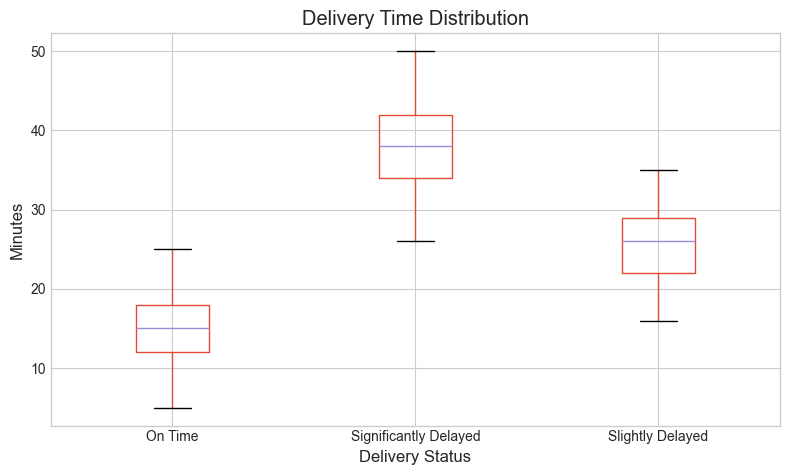

In [ ]:
orders.boxplot(column='delivery_time_min', by='delivery_status', figsize=(8,5))

plt.title("Delivery Time Distribution")
plt.suptitle("")
plt.xlabel("Delivery Status")
plt.ylabel("Minutes")

plt.tight_layout()
plt.show()

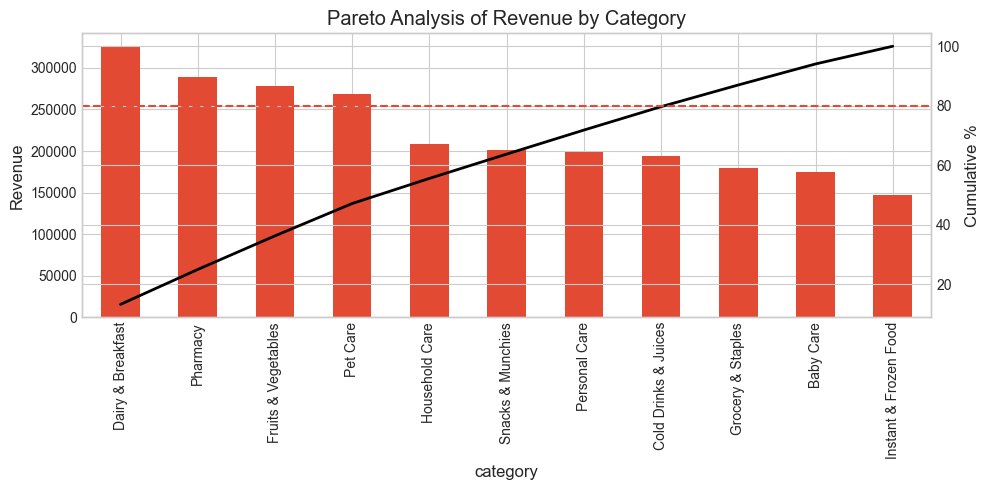

In [ ]:
pareto = merged.groupby('category')['price'].sum().sort_values(ascending=False)

cum_pct = pareto.cumsum() / pareto.sum() * 100

fig, ax1 = plt.subplots(figsize=(10,5))

pareto.plot(kind='bar', ax=ax1)
ax1.set_ylabel('Revenue')

ax2 = ax1.twinx()
cum_pct.plot(ax=ax2, color='black', linewidth=2)
ax2.set_ylabel('Cumulative %')

ax2.axhline(80, linestyle='--')
plt.title("Pareto Analysis of Revenue by Category")

plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

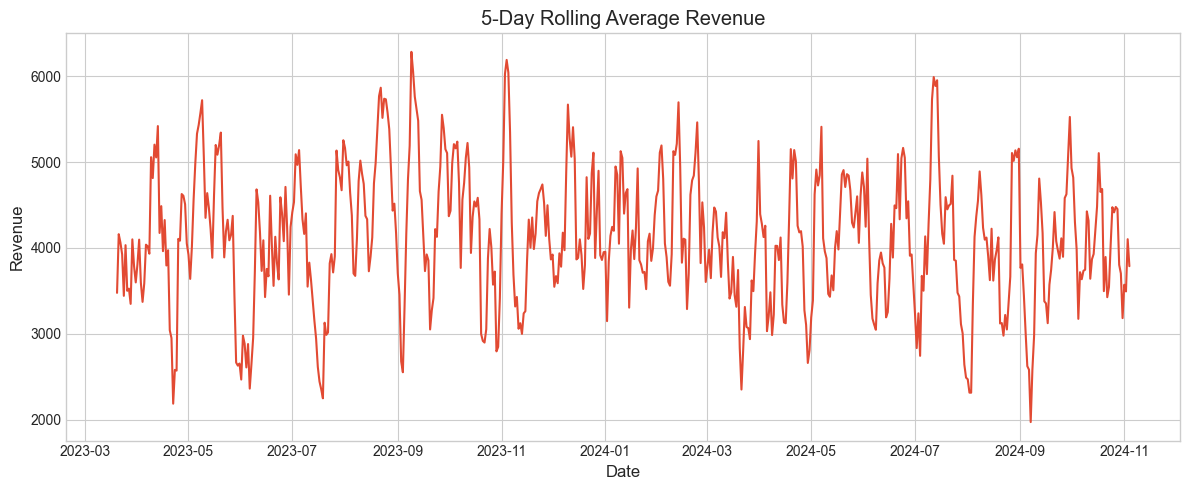

In [ ]:
daily_rev = merged.groupby('order_day')['price'].sum()

daily_rev.rolling(5).mean().plot(figsize=(12,5))
plt.title("5-Day Rolling Average Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [159]:
total_sales = orders['order_total'].sum()
total_orders = orders.shape[0]
avg_price = orders['order_total'].mean()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_price)


Total Sales: 11009308.5
Total Orders: 5000
Average Order Value: 2201.8617


Key Business Insights:
- Total revenue generated from orders is shown above
- Total number of orders indicates platform activity
- Average order value helps understand customer spending behavior

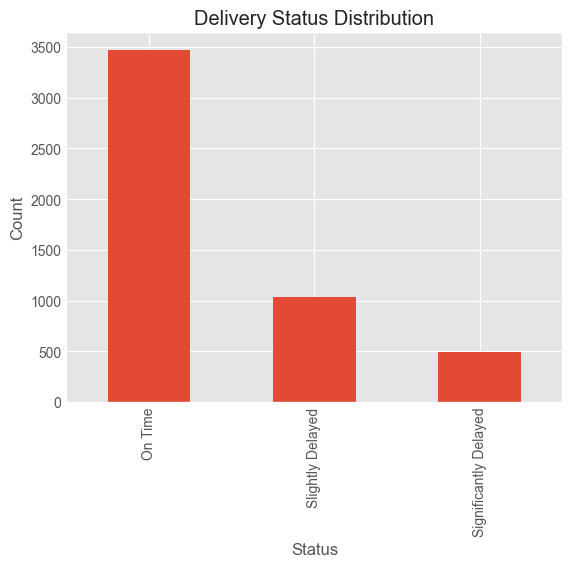

In [160]:
orders['delivery_status'].value_counts().plot(kind='bar')
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Insight:
Most orders are delivered on time, indicating strong delivery performance.


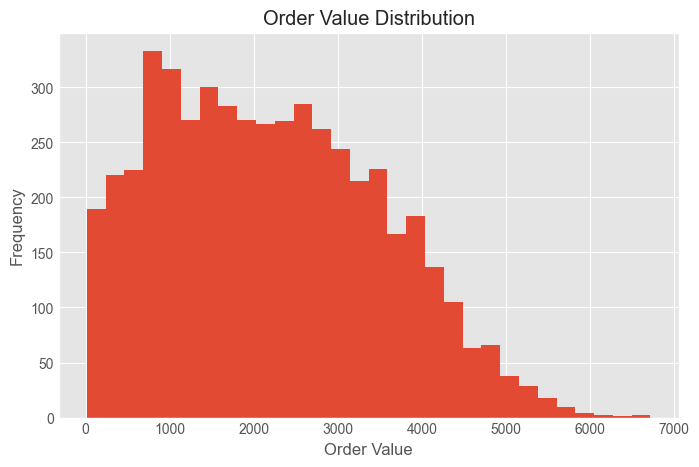

In [161]:
plt.figure(figsize=(8,5))
plt.hist(orders['order_total'], bins=30)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

### Insight
Most orders fall within a specific price range, indicating typical customer spending behavior.

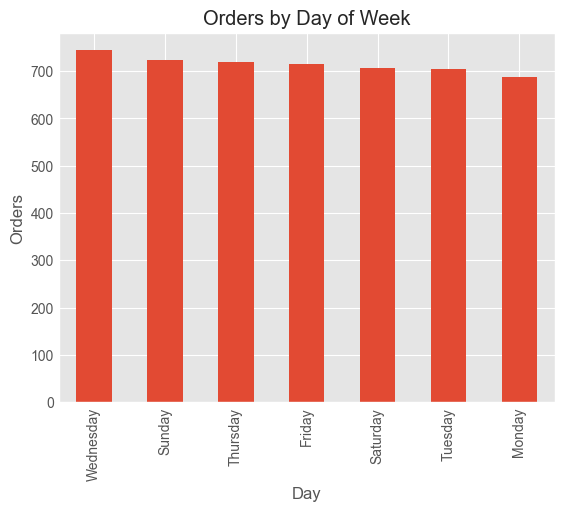

In [162]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders['day'] = orders['order_date'].dt.day_name()

orders['day'].value_counts().plot(kind='bar')
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Orders")
plt.show()

### Insight
Certain days show higher order volume, useful for staffing and inventory planning.

In [163]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
